In [1]:
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

from folium.plugins import HeatMap
import folium

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
df = pd.read_csv(r"C:\Users\jfurs\@Python\OpenClassrooms\DS\P4\2016_Building_Energy_Benchmarking.csv")

In [3]:
df

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3.946027e+06,12764.529300,1.276453e+06,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3.242851e+06,51450.816410,5.145082e+06,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,4.952666e+07,14938.000000,1.493800e+06,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2.768924e+06,18112.130860,1.811213e+06,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5.368607e+06,88039.984380,8.803998e+06,False,NaN,Compliant,NaN,505.01,2.88
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3371,50222,2016,Nonresidential COS,Office,Horticulture building,1600 S Dakota St,Seattle,WA,NaN,1624049080,...,1.536550e+05,5.242709e+05,3254.750244,3.254750e+05,True,NaN,Error - Correct Default Data,NaN,20.94,1.70
3372,50223,2016,Nonresidential COS,Other,International district/Chinatown CC,719 8th Ave S,Seattle,WA,NaN,3558300000,...,1.162210e+05,3.965461e+05,5537.299805,5.537300e+05,False,NaN,Compliant,NaN,32.17,2.01
3373,50224,2016,Nonresidential COS,Other,Queen Anne Pool,1920 1st Ave W,Seattle,WA,NaN,1794501150,...,5.252517e+05,1.792159e+06,39737.390630,3.973739e+06,False,NaN,Compliant,NaN,223.54,16.99
3374,50225,2016,Nonresidential COS,Mixed Use Property,South Park Community Center,8319 8th Ave S,Seattle,WA,NaN,7883603155,...,1.022480e+05,3.488702e+05,3706.010010,3.706010e+05,False,NaN,Compliant,NaN,22.11,1.57


# SETUP

In [4]:
# cols useless in df
useless = ["TaxParcelIdentificationNumber", "ZipCode", "PropertyName", "Address", "OSEBuildingID",
           "ListOfAllPropertyUseTypes", "LargestPropertyUseType", "LargestPropertyUseTypeGFA", "SecondLargestPropertyUseType", 
           "SecondLargestPropertyUseTypeGFA", "ThirdLargestPropertyUseType", "ThirdLargestPropertyUseTypeGFA", "YearsENERGYSTARCertified", 
           "SiteEUI(kBtu/sf)", "SiteEUIWN(kBtu/sf)", "SourceEUI(kBtu/sf)", "DefaultData", "Comments", "DataYear", "OSEBuildingID"]

In [5]:
# keep compliant
df = df[df["ComplianceStatus"] == "Compliant"]

# only keep nr
nr = [
    'NonResidential',
    'Nonresidential COS',
    'Nonresidential WA',
    'SPS-District K-12'
]

df = df[df["BuildingType"].isin(nr)]
df = df.drop(columns=useless)

In [6]:
def remove_outliers_cap(series, lower_quantile=0.005, upper_quantile=0.995):
    lower_bound = series.quantile(lower_quantile)
    upper_bound = series.quantile(upper_quantile)
    return series[(series >= lower_bound) & (series <= upper_bound)]

ghg_filtered = remove_outliers_cap(df['TotalGHGEmissions'].dropna())
energy_filtered = remove_outliers_cap(df['SiteEnergyUse(kBtu)'].dropna())

In [7]:
# dropping again useless cols 
df = df.drop(columns=["Outlier", "NaturalGas(therms)", "Electricity(kWh)", "State", "City", "CouncilDistrictCode"])

# Analyse Univariée

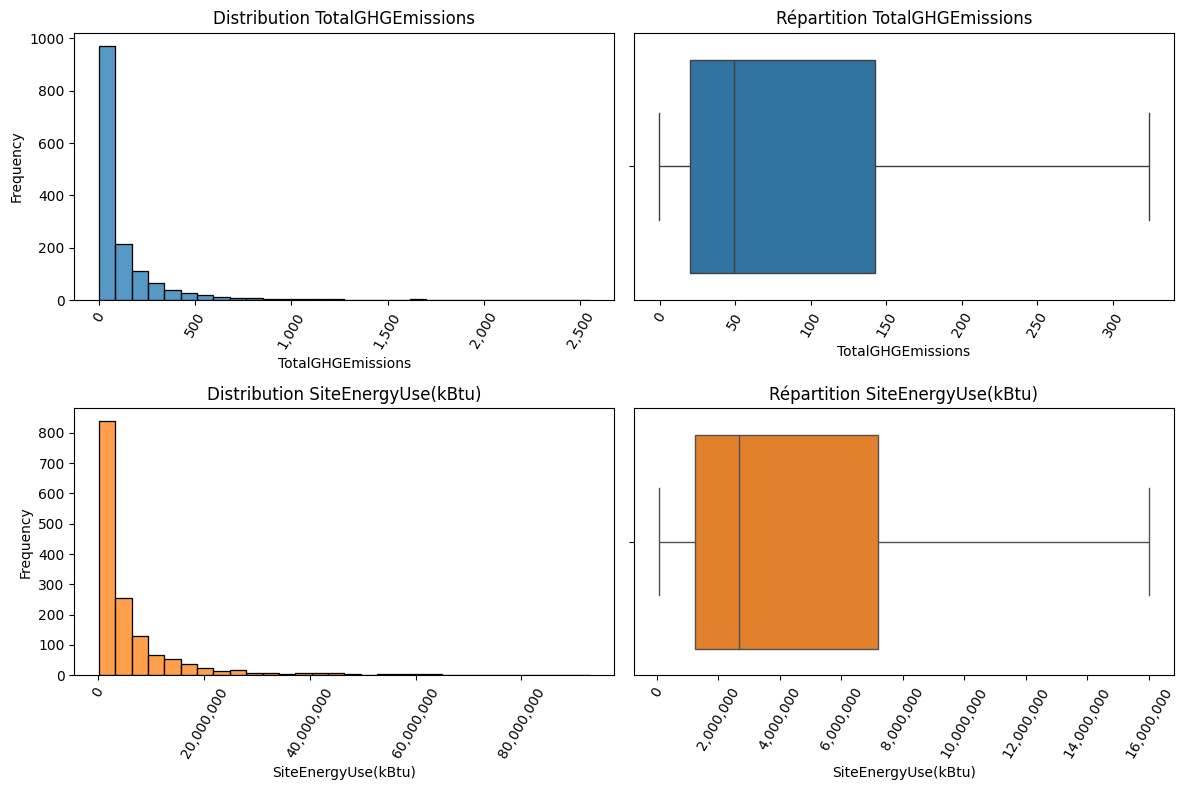

In [8]:
# Univariate : TotalGHGEmissions & SiteEnergyUse(kBtu)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Histogram TotalGHGEmissions
sns.histplot(ghg_filtered, bins=30, ax=axs[0, 0], color='#1f77b4')
axs[0, 0].set_title('Distribution TotalGHGEmissions')
axs[0, 0].set_xlabel('TotalGHGEmissions')
axs[0, 0].set_ylabel('Frequency')
axs[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axs[0, 0].tick_params(axis='x', labelrotation=60)

# Boxplot TotalGHGEmissions
sns.boxplot(x=df['TotalGHGEmissions'].dropna(), ax=axs[0, 1], color='#1f77b4', showfliers=False)
axs[0, 1].set_title('Répartition TotalGHGEmissions')
axs[0, 1].set_xlabel('TotalGHGEmissions')
axs[0, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axs[0, 1].tick_params(axis='x', labelrotation=60)

# Histogram SiteEnergyUse(kBtu)
sns.histplot(energy_filtered, bins=30, ax=axs[1, 0], color='#ff7f0e')
axs[1, 0].set_title('Distribution SiteEnergyUse(kBtu)')
axs[1, 0].set_xlabel('SiteEnergyUse(kBtu)')
axs[1, 0].set_ylabel('Frequency')
axs[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axs[1, 0].tick_params(axis='x', labelrotation=60)

# Boxplot SiteEnergyUse(kBtu)
sns.boxplot(x=df['SiteEnergyUse(kBtu)'].dropna(), ax=axs[1, 1], color='#ff7f0e', showfliers=False)
axs[1, 1].set_title('Répartition SiteEnergyUse(kBtu)')
axs[1, 1].set_xlabel('SiteEnergyUse(kBtu)')
axs[1, 1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axs[1, 1].tick_params(axis='x', labelrotation=60)

plt.tight_layout()
plt.show()

# Analyse Bivariée

## TotalGHGEmissions

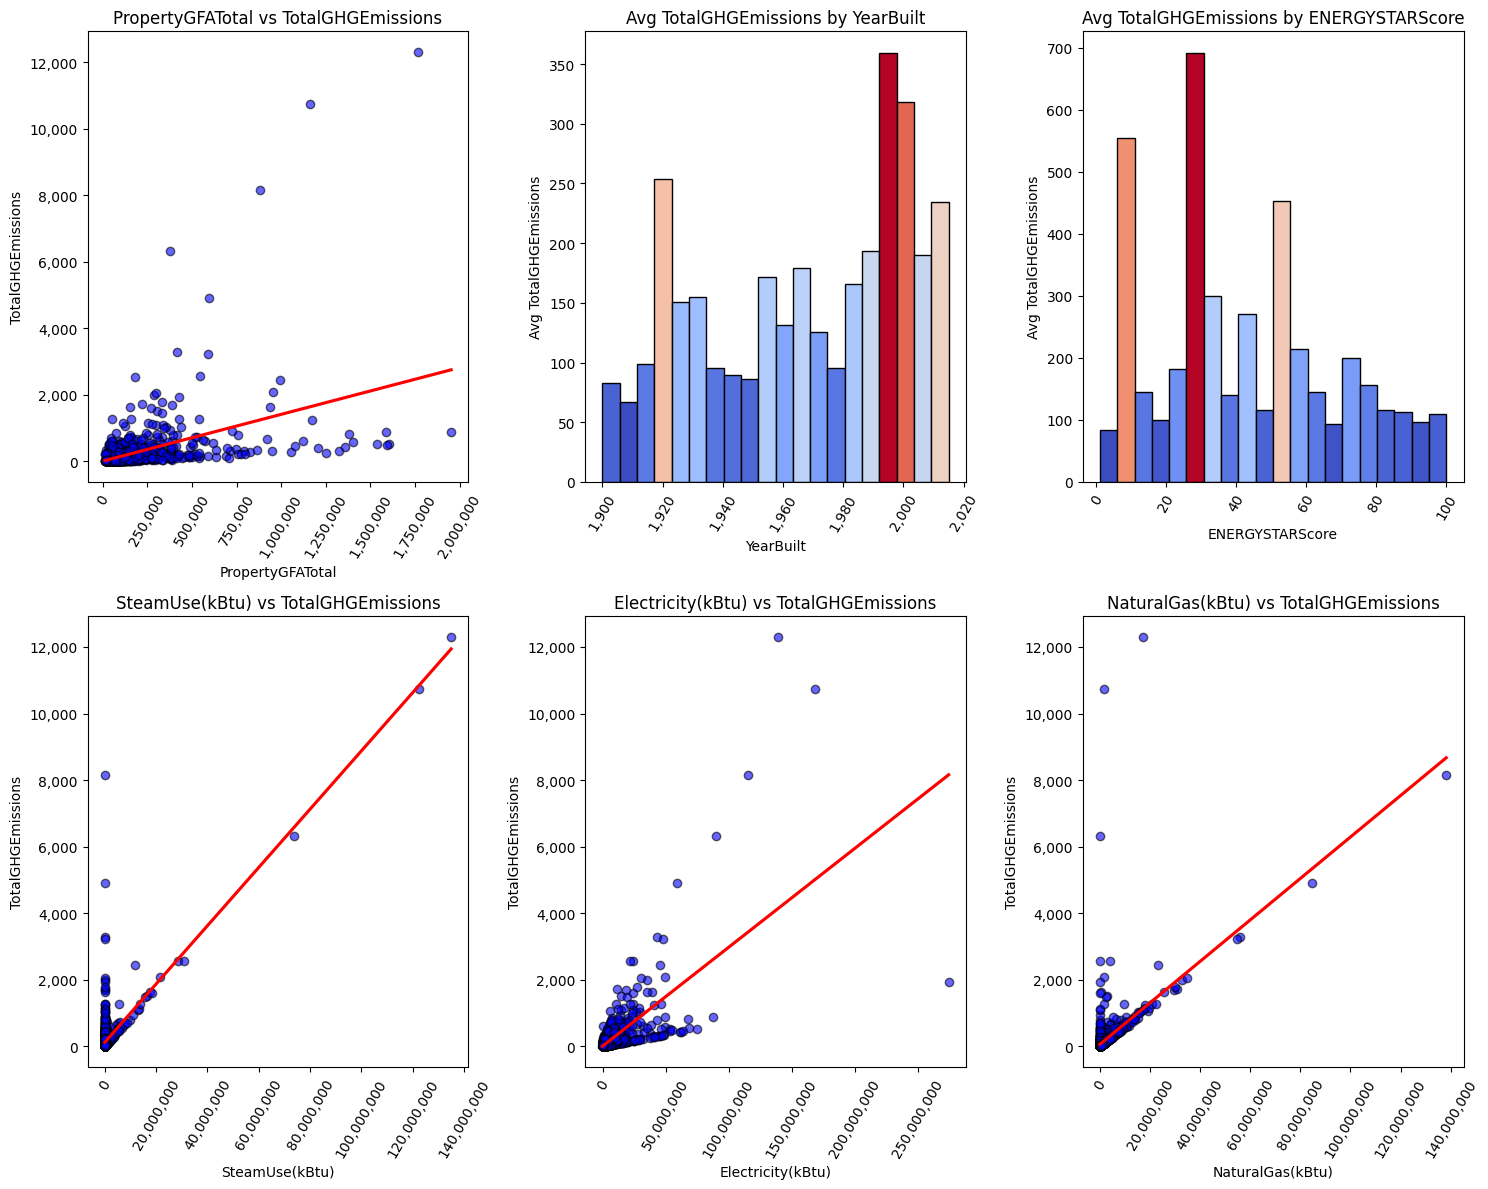

In [9]:
fig, axs = plt.subplots(2, 3, figsize=(15, 12))
axs = axs.flatten()

lst_cols_energy_use = ["PropertyGFATotal", "YearBuilt", "ENERGYSTARScore", "SteamUse(kBtu)", "Electricity(kBtu)", "NaturalGas(kBtu)"]

for ind, col in enumerate(lst_cols_energy_use):
    if col in ["ENERGYSTARScore", "YearBuilt"]:
        data = df[[col, 'TotalGHGEmissions']].dropna()

        bins = np.linspace(data[col].min(), data[col].max(), 21)
        data['bin'] = pd.cut(data[col], bins)

        # Compute average emissions per bin
        avg_emissions = data.groupby('bin', observed=True)['TotalGHGEmissions'].mean()
        bin_centers = [interval.mid for interval in avg_emissions.index]
        widths = [interval.right - interval.left for interval in avg_emissions.index]

        # Norm values for colormap
        norm = mcolors.Normalize(vmin=avg_emissions.min(), vmax=avg_emissions.max())
        cmap = plt.cm.coolwarm

        # Plot
        axs[ind].clear()
        for i in range(len(avg_emissions)):
            color = cmap(norm(avg_emissions.iloc[i]))
            axs[ind].bar(bin_centers[i], avg_emissions.iloc[i], width=widths[i],
                         color=color, edgecolor='black')

        axs[ind].set_title(f'Avg TotalGHGEmissions by {col}')
        axs[ind].set_xlabel(col)
        axs[ind].set_ylabel('Avg TotalGHGEmissions')

    else:
        sns.regplot(data=df, x=col, y='TotalGHGEmissions', ax=axs[ind], ci=None,
                    scatter_kws={'alpha': 0.6, 'color': 'blue', 'edgecolor': 'black'},
                    line_kws={'color': 'red'})
        axs[ind].set_title(f'{col} vs TotalGHGEmissions')
        axs[ind].set_xlabel(col)
        axs[ind].set_ylabel('TotalGHGEmissions')

    # --- FORCE PLAIN NUMBERS & ROTATE X TICKS ---
    axs[ind].ticklabel_format(style='plain', axis='y')  # y-axis plain
    axs[ind].ticklabel_format(style='plain', axis='x')  # x-axis plain
    axs[ind].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    axs[ind].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    axs[ind].tick_params(axis='x', labelrotation=60)  # rotate x labels

for j in range(len(lst_cols_energy_use), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


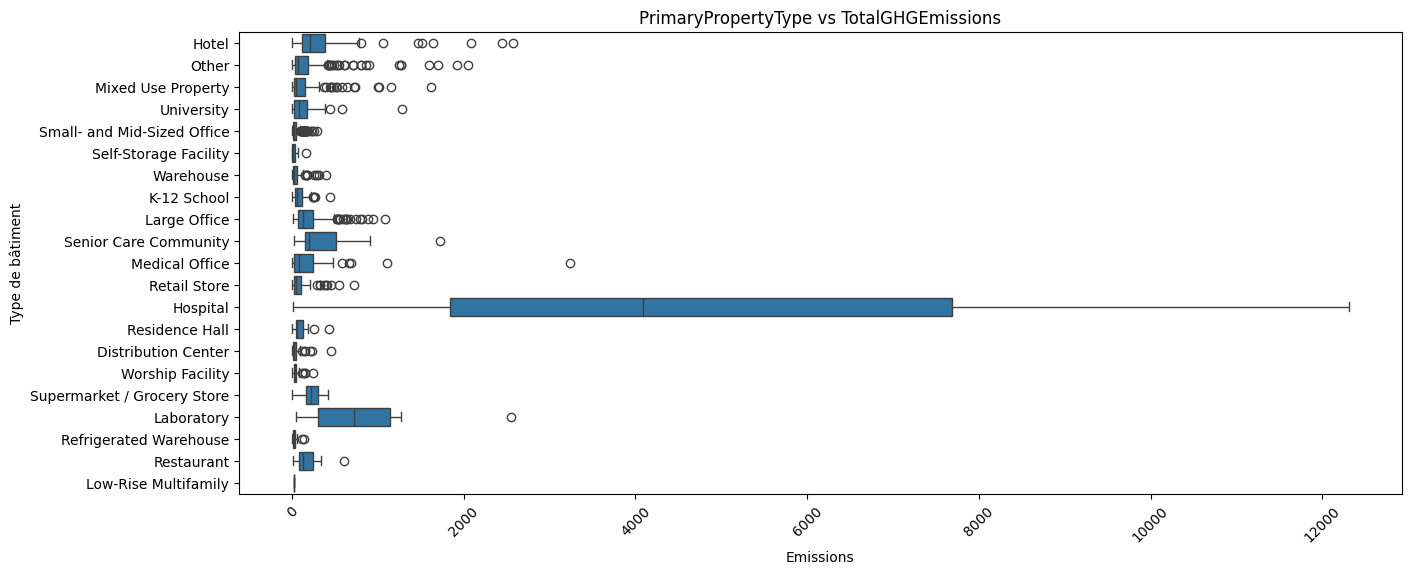

In [15]:
#  Some types emit more (e.g. hospitals, offices)

plt.figure(figsize=(15,6))
sns.boxplot(data=df, x='TotalGHGEmissions', y='PrimaryPropertyType')
plt.xticks(rotation=45)  # Rotate labels for better readability
plt.title('PrimaryPropertyType vs TotalGHGEmissions')
plt.xlabel('Emissions')
plt.ylabel('Type de bâtiment')
plt.show()

In [11]:
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=12)

# Add heatmap
heat_data = df[['Latitude', 'Longitude', 'TotalGHGEmissions']].values.tolist()
HeatMap(heat_data, radius=25, max_zoom=13).add_to(m)

# Group by region and get mean lat/lon (centroid)
region_centers = df.groupby('Neighborhood')[['Latitude', 'Longitude']].mean().reset_index()

# Labels for each region
for _, row in region_centers.iterrows():
    folium.map.Marker(
        [row['Latitude'], row['Longitude']],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size:14px; 
                color:black; 
                font-weight:bold; 
                text-shadow: 1px 1px white; 
                transform: rotate(90deg);
                transform-origin: left top;
            ">
                {row['Neighborhood']}
            </div>
            """
        )
    ).add_to(m)

m.save("heatmap_with_region_labels_emissions.html")

m

## SiteEnergyUse(kBtu)

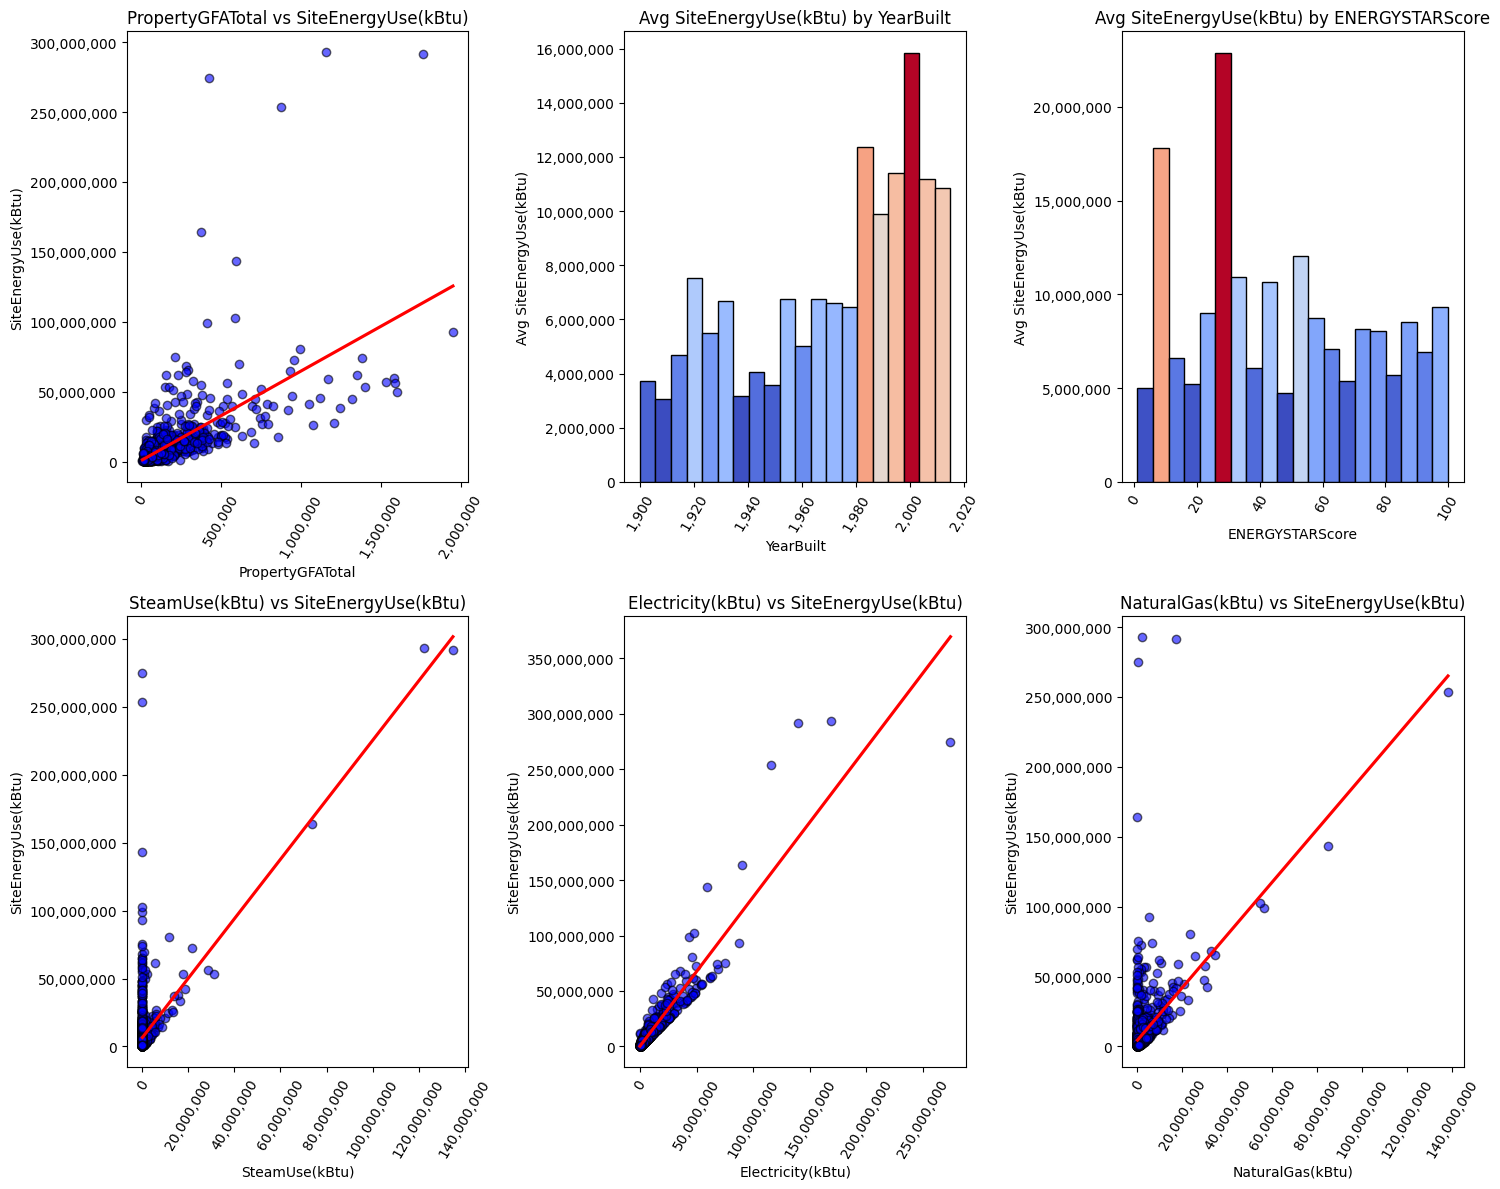

In [12]:
import matplotlib.ticker as mticker

fig, axs = plt.subplots(2, 3, figsize=(15, 12))
axs = axs.flatten()

lst_cols_energy_use = ["PropertyGFATotal", "YearBuilt", "ENERGYSTARScore", "SteamUse(kBtu)", "Electricity(kBtu)", "NaturalGas(kBtu)"]

for ind, col in enumerate(lst_cols_energy_use):
    if col in ["ENERGYSTARScore", "YearBuilt"]:

        data = df[[col, 'SiteEnergyUse(kBtu)']].dropna()

        bins = np.linspace(data[col].min(), data[col].max(), 21)
        data['bin'] = pd.cut(data[col], bins)

        # Compute average emissions per bin
        avg_emissions = data.groupby('bin', observed=True)['SiteEnergyUse(kBtu)'].mean()
        bin_centers = [interval.mid for interval in avg_emissions.index]
        widths = [interval.right - interval.left for interval in avg_emissions.index]

        # Norm values for colormap
        norm = mcolors.Normalize(vmin=avg_emissions.min(), vmax=avg_emissions.max())
        cmap = plt.cm.coolwarm

        # Plot
        axs[ind].clear()
        for i in range(len(avg_emissions)):
            color = cmap(norm(avg_emissions.iloc[i]))
            axs[ind].bar(bin_centers[i], avg_emissions.iloc[i], width=widths[i],
                         color=color, edgecolor='black')

        axs[ind].set_title(f'Avg SiteEnergyUse(kBtu) by {col}')
        axs[ind].set_xlabel(col)
        axs[ind].set_ylabel('Avg SiteEnergyUse(kBtu)')

    else:
        sns.regplot(data=df, x=col, y='SiteEnergyUse(kBtu)', ax=axs[ind], ci=None,
                    scatter_kws={'alpha': 0.6, 'color': 'blue', 'edgecolor': 'black'},
                    line_kws={'color': 'red'})
        axs[ind].set_title(f'{col} vs SiteEnergyUse(kBtu)')
        axs[ind].set_xlabel(col)
        axs[ind].set_ylabel('SiteEnergyUse(kBtu)')

    # --- FORCE PLAIN NUMBERS & ROTATE X TICKS ---
    axs[ind].ticklabel_format(style='plain', axis='y')  # y-axis plain
    axs[ind].ticklabel_format(style='plain', axis='x')  # x-axis plain
    axs[ind].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    axs[ind].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    axs[ind].tick_params(axis='x', labelrotation=60)  # rotate x labels

for j in range(len(lst_cols_energy_use), len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()


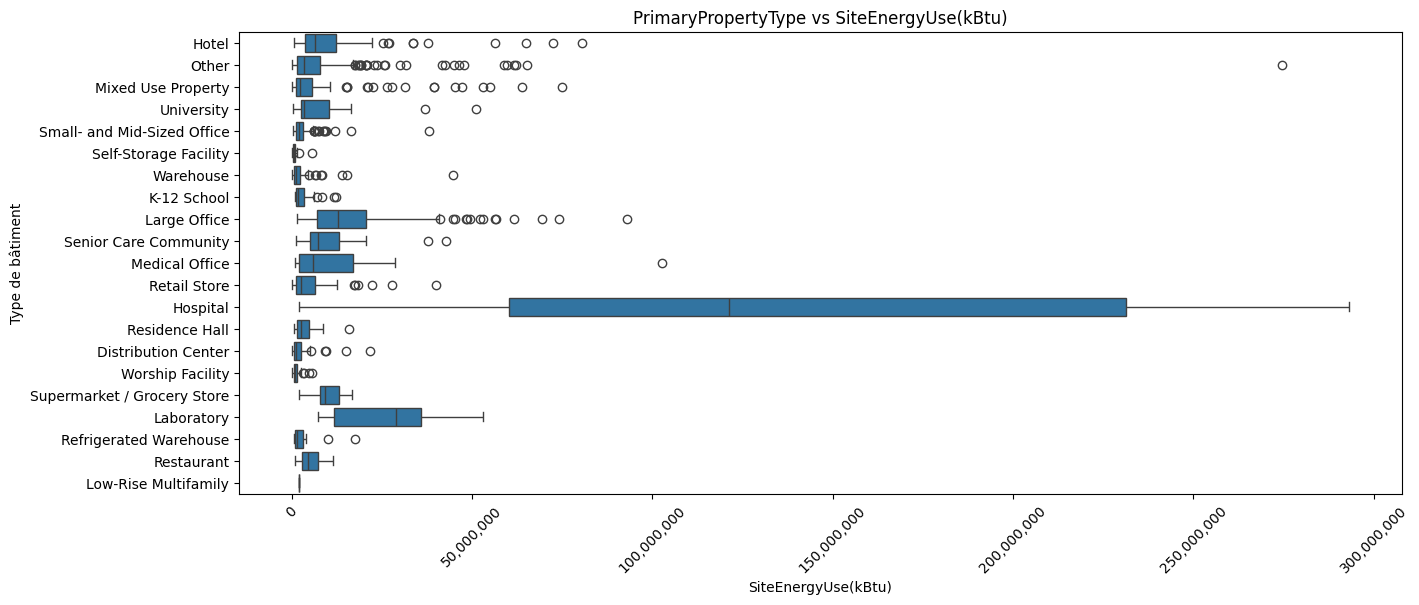

In [14]:
# Patterns by type

plt.figure(figsize=(15,6))
sns.boxplot(data=df, x='SiteEnergyUse(kBtu)', y='PrimaryPropertyType')

ax = plt.gca()
ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.xticks(rotation=45)
plt.title('PrimaryPropertyType vs SiteEnergyUse(kBtu)')
plt.xlabel('SiteEnergyUse(kBtu)')
plt.ylabel('Type de bâtiment')
plt.show()

In [31]:
m = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=12)

# Add heatmap
heat_data = df[['Latitude', 'Longitude', 'SiteEnergyUse(kBtu)']].values.tolist()
HeatMap(heat_data, radius=25, max_zoom=13).add_to(m)

# 1. Group by region and calculate mean lat/lon (centroid)
region_centers = df.groupby('Neighborhood')[['Latitude', 'Longitude']].mean().reset_index()

# 2. Add labels for each region
for _, row in region_centers.iterrows():
    folium.map.Marker(
        [row['Latitude'], row['Longitude']],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size:14px; 
                color:black; 
                font-weight:bold; 
                text-shadow: 1px 1px white; 
                transform: rotate(90deg);
                transform-origin: left top;
            ">
                {row['Neighborhood']}
            </div>
            """
        )
    ).add_to(m)

# Save the map
m.save("heatmap_with_region_labels_electricite.html")

m

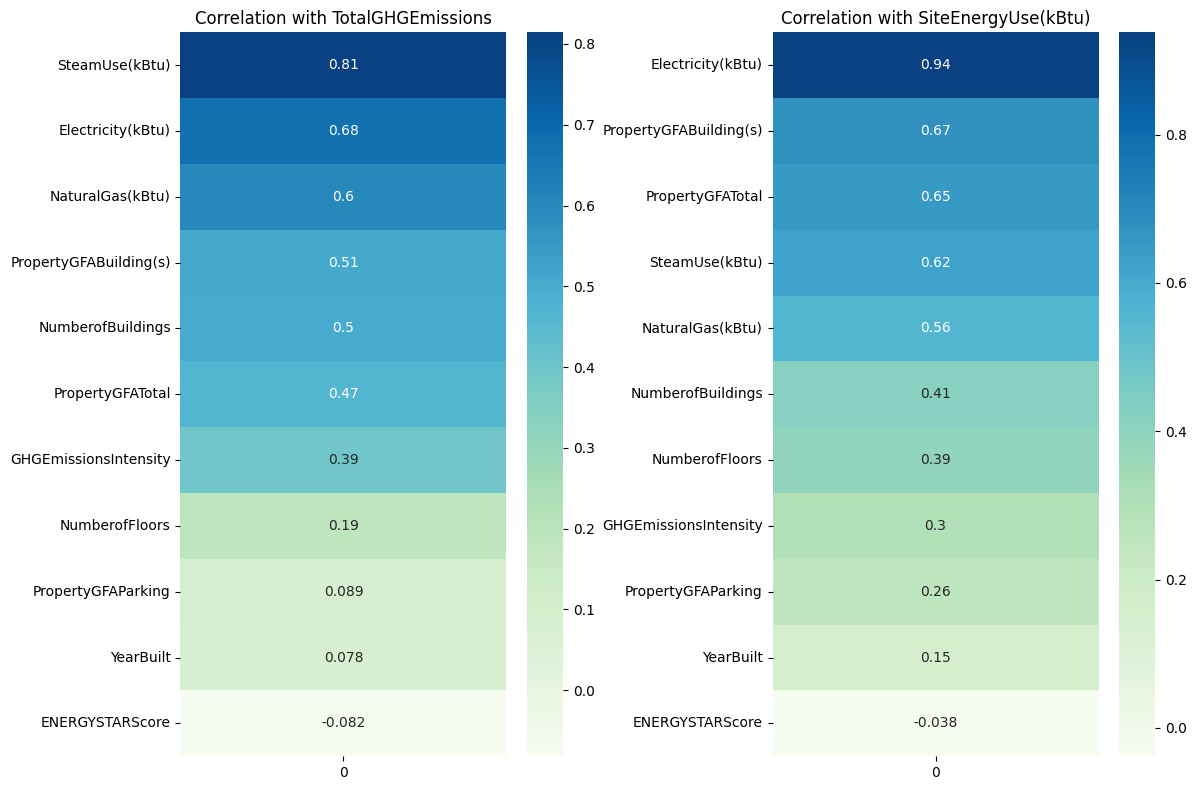

In [29]:
features = ["YearBuilt", "NumberofBuildings", "NumberofFloors", "PropertyGFATotal", "PropertyGFAParking", "PropertyGFABuilding(s)",  "ENERGYSTARScore", 
            "SteamUse(kBtu)", "Electricity(kBtu)", "NaturalGas(kBtu)", "GHGEmissionsIntensity"]

targets = ["TotalGHGEmissions", "SiteEnergyUse(kBtu)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 8))

for i, target in enumerate(targets):
    corr_with_target = df[features].corrwith(df[target]).sort_values(ascending=False)
    sns.heatmap(corr_with_target.to_frame(), cmap='GnBu', annot=True, ax=axes[i])
    axes[i].set_title(f'Correlation with {target}')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

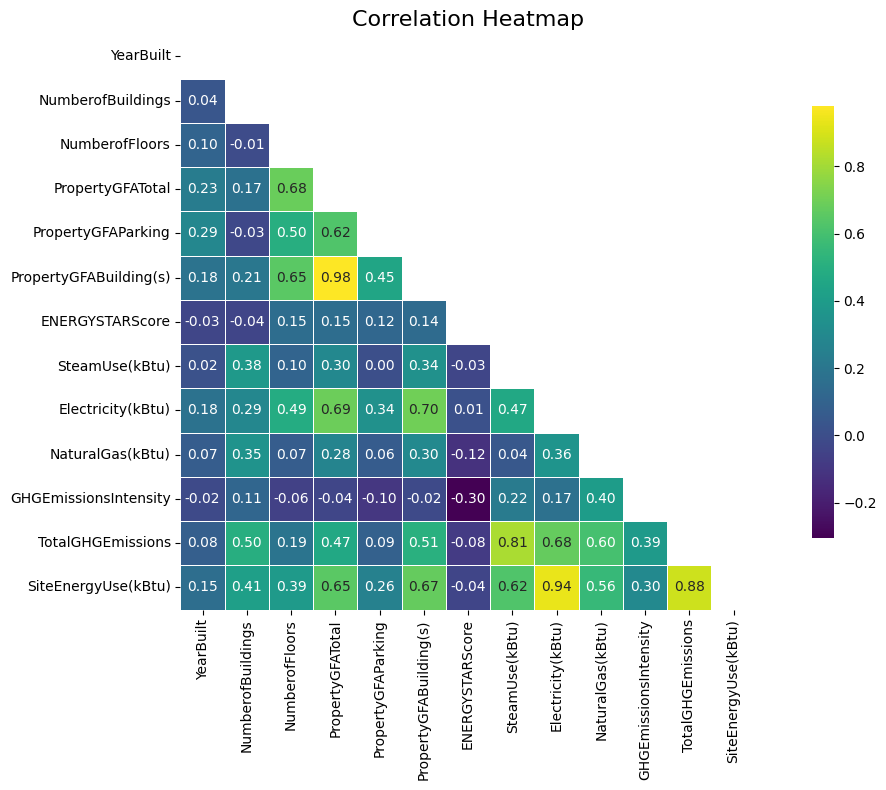

In [30]:
df_tmp = df[["YearBuilt", "NumberofBuildings", "NumberofFloors", "PropertyGFATotal", "PropertyGFAParking", "PropertyGFABuilding(s)",  "ENERGYSTARScore", 
            "SteamUse(kBtu)", "Electricity(kBtu)", "NaturalGas(kBtu)", "GHGEmissionsIntensity", "TotalGHGEmissions", "SiteEnergyUse(kBtu)"]]

corr = df_tmp.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap='viridis', annot=True, fmt=".2f", square=True, linewidths=.5, cbar_kws={"shrink": .75})

plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()

# Feature Engineering

In [63]:
energy_flags = {
    'Hotel': (1, 1, 1),
    'Other': (1, 1, 0),
    'Mixed Use Property': (1, 1, 1),
    'University': (1, 1, 1),
    'Small- and Mid-Sized Office': (1, 1, 0),
    'Self-Storage Facility': (1, 0, 0),
    'Warehouse': (1, 0, 0),
    'K-12 School': (1, 1, 1),
    'Large Office': (1, 1, 1),
    'Senior Care Community': (1, 1, 0),
    'Medical Office': (1, 1, 0),
    'Retail Store': (1, 1, 0),
    'Hospital': (1, 1, 1),
    'Residence Hall': (1, 1, 1),
    'Distribution Center': (1, 0, 0),
    'Worship Facility': (1, 1, 0),
    'Supermarket / Grocery Store': (1, 1, 0),
    'Laboratory': (1, 1, 1),
    'Refrigerated Warehouse': (1, 0, 0),
    'Restaurant': (1, 1, 0),
    'Low-Rise Multifamily': (1, 1, 0)
}

df[['Electricity_usage', 'NaturalGas_usage', 'Steam_usage']] = df['PrimaryPropertyType'].apply(
    lambda bt: pd.Series(energy_flags[bt]))

In [64]:
# YearBuilt en Bins
bins = [1899, 1939, 1959, 1979, 1999, 2009, 2016] 
labels = ['1900-1939', '1940-1959', '1960-1979', '1980-1999', '2000-2009', '2010-2016']
df['building_age_category'] = pd.cut(df['YearBuilt'], bins=bins, labels=labels, right=True)

# Number of floors en Bins
bins = [-1, 2, 5, 10, 30, 99]
labels = ['0-1', '2-5', '6-10', '11-30', '31+']
df['building_height_category'] = pd.cut(df['NumberofFloors'], bins=bins, labels=labels, right=True)

# Ratio parking et rm parkingGFA : parking - total / total
df["ratio_parking"] = df["PropertyGFAParking"] / df["PropertyGFATotal"]

# rm Intensity
df = df.drop(columns=["PropertyGFAParking", "GHGEmissionsIntensity", "Neighborhood"])

In [65]:
df.head()

,BuildingType,PrimaryPropertyType,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFABuilding(s),ENERGYSTARScore,...,Electricity(kBtu),NaturalGas(kBtu),ComplianceStatus,TotalGHGEmissions,Electricity_usage,NaturalGas_usage,Steam_usage,building_age_category,building_height_category,ratio_parking
0,NonResidential,Hotel,47.61220,-122.33799,1927,1.0,12,88434,88434,60.0,...,3946027.0,1276453.0,Compliant,249.98,1,1,1,1900-1939,11-30,0.000000
1,NonResidential,Hotel,47.61317,-122.33393,1996,1.0,11,103566,88502,61.0,...,3242851.0,5145082.0,Compliant,295.86,1,1,1,1980-1999,11-30,0.145453
2,NonResidential,Hotel,47.61393,-122.33810,1969,1.0,41,956110,759392,43.0,...,49526664.0,1493800.0,Compliant,2089.28,1,1,1,1960-1979,31+,0.205748
3,NonResidential,Hotel,47.61412,-122.33664,1926,1.0,10,61320,61320,56.0,...,2768924.0,1811213.0,Compliant,286.43,1,1,1,1900-1939,6-10,0.000000
4,NonResidential,Hotel,47.61375,-122.34047,1980,1.0,18,175580,113580,75.0,...,5368607.0,8803998.0,Compliant,505.01,1,1,1,1980-1999,11-30,0.353115


In [66]:
df_emissions = df[["NumberofBuildings", "PropertyGFATotal", "PropertyGFABuilding(s)", "ENERGYSTARScore", "SteamUse(kBtu)", "Electricity(kBtu)", 
                   "NaturalGas(kBtu)", "TotalGHGEmissions", "Electricity_usage", "NaturalGas_usage", "Steam_usage", "building_age_category", 
                   "building_height_category", "ratio_parking", "PrimaryPropertyType"]]

df_energy_use = df[["NumberofBuildings", "PropertyGFATotal", "PropertyGFABuilding(s)", "SteamUse(kBtu)", "Electricity(kBtu)", "NaturalGas(kBtu)", 
                    "SiteEnergyUse(kBtu)", "Electricity_usage", "NaturalGas_usage", "Steam_usage", "building_age_category", 
                   "building_height_category", "ratio_parking", "PrimaryPropertyType"]]

# Saving DFs

In [67]:
df_emissions.to_csv(r"C:\Users\jfurs\@Python\OpenClassrooms\DS\P4\emissions\df_emissions.csv", index=False)
df_energy_use.to_csv(r"C:\Users\jfurs\@Python\OpenClassrooms\DS\P4\energy_use\df_energy_use.csv", index=False)